In [154]:
from typing import Any
from typing import Self

from collections import deque

import numpy as np
import networkx as nx

In [155]:
class Node:
    def __init__(self, pos: tuple[int, int], data: Any):
        self.pos = pos
        self.data = data
        self.neighbors: list[Node] = []
        self.visited: bool = False
        self.parent: Node | None = None

    def connect(self, other: Self) -> None:
        if other not in self.neighbors:
            self.neighbors.append(other)
            other.neighbors.append(self)

    def __repr__(self) -> str:
        return f"{self.pos}{len(self.neighbors)}{'+' if self.visited else '-'}"

    def __str__(self) -> str:
        return repr(self)

    def __len__(self) -> None:
        return len(self.neighbors)

    # def __eq__(self, other: Self) -> bool:
    #     return self.pos == other.pos

In [156]:
class Labyrinth:
    def __init__(self, height: int, width: int, alpha: float = 0.6):
        self.height = height
        self.width = width
        self.nodes: dict[tuple[int, int], Node] = {}
        self.alpha = alpha

    def generate(self) -> None:
        for i in range(self.height):
            for j in range(self.width):
                node = Node(pos=(i, j), data=i * self.width + j)
                self.nodes[node.pos] = node

        for h in range(1, self.height):
            if np.random.rand() < self.alpha:
                self.nodes[(h, 0)].connect(self.nodes[(h - 1, 0)])
        for w in range(1, self.width):
            if np.random.rand() < self.alpha:
                self.nodes[(0, w)].connect(self.nodes[(0, w - 1)])
        for h in range(1, self.height):
            for w in range(1, self.width):
                if np.random.rand() < self.alpha:
                    self.nodes[(h, w)].connect(self.nodes[(h, w - 1)])
                if np.random.rand() < self.alpha:
                    self.nodes[(h, w)].connect(self.nodes[(h - 1, w)])

        self.root = self.nodes[(0, 0)]

    def to_nx(self) -> nx.DiGraph:
        g = nx.Graph(data=None)
        pos = {}

        for node in self.nodes.values():
            g.add_node(node.pos, data=node.data)
            pos[node.pos] = node.pos

            for neighbor in node.neighbors:
                if neighbor.pos[0] <= node.pos[0] or neighbor.pos[1] <= node.pos[1]:
                    g.add_edge(node.pos, neighbor.pos)

        return g, pos

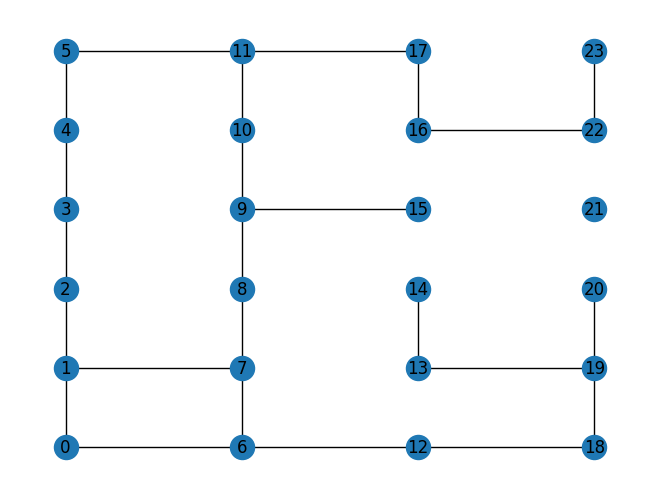

In [157]:
HEIGHT, WIDTH = 4, 6
ALPHA = 0.7

lab = Labyrinth(height=HEIGHT, width=WIDTH, alpha=ALPHA)

lab.generate()

g, pos = lab.to_nx()

nx.draw(g, labels=nx.get_node_attributes(g, "data"), pos=pos)

In [ ]:
def breadth_first_search_iterative(root: Node, target: Node):
    stack = deque([root])

    while len(stack) > 0:
        node = stack.pop()
        print(f"{node=} {len(stack)=}")
        if not node.visited:
            node.visited = True
            if node == target:
                return True
            else:
                next_nodes = [n for n in node.neighbors if not n.visited]
                print(next_nodes)
                if len(next_nodes) == 0:
                    continue
                else:
                    for n in next_nodes:
                        n.parent = node
                        stack.append(n)

    return False


for node in lab.nodes.values():
    node.visited = False
    node.parent = None

root = lab.nodes[0, 0]
target = lab.nodes[0, 3]
result = breadth_first_search_iterative(root=root, target=target)
result

node=(0, 0)1- len(stack)=0
[(1, 0)2-]
node=(1, 0)2- len(stack)=0
[(2, 0)2-]
node=(2, 0)2- len(stack)=0
[(2, 1)2-]
node=(2, 1)2- len(stack)=0
[(1, 1)3-]
node=(1, 1)3- len(stack)=0
[(0, 1)2-, (1, 2)4-]
node=(1, 2)4- len(stack)=1
[(0, 2)2-, (1, 3)3-, (2, 2)2-]
node=(2, 2)2- len(stack)=3
[(2, 3)3-]
node=(2, 3)3- len(stack)=3
[(1, 3)3-, (3, 3)1-]
node=(3, 3)1- len(stack)=4
[]
node=(1, 3)3- len(stack)=3
[(1, 4)4-]
node=(1, 4)4- len(stack)=3
[(0, 4)3-, (1, 5)3-, (2, 4)3-]
node=(2, 4)3- len(stack)=5
[(2, 5)3-, (3, 4)2-]
node=(3, 4)2- len(stack)=6
[(3, 5)2-]
node=(3, 5)2- len(stack)=6
[(2, 5)3-]
node=(2, 5)3- len(stack)=6
[(1, 5)3-]
node=(1, 5)3- len(stack)=6
[(0, 5)2-]
node=(0, 5)2- len(stack)=6
[(0, 4)3-]
node=(0, 4)3- len(stack)=6
[(0, 3)1-]
node=(0, 3)1- len(stack)=6


True

In [150]:
current = target
path = [current.pos]
while current.parent is not None:
    current = current.parent
    path.append(current.pos)

path

[(0, 3),
 (0, 4),
 (0, 5),
 (1, 5),
 (2, 5),
 (3, 5),
 (3, 4),
 (2, 4),
 (1, 4),
 (1, 3),
 (2, 3),
 (2, 2),
 (1, 2),
 (1, 1),
 (2, 1),
 (2, 0),
 (1, 0),
 (0, 0)]

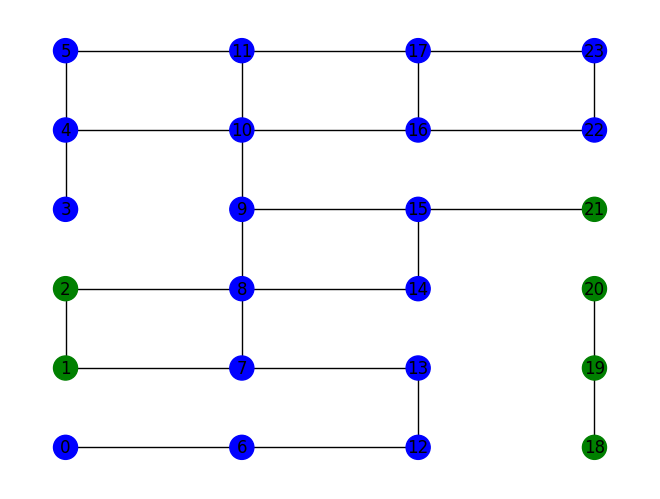

In [151]:
color_map = []
for node in g:
    if node in path:
        color_map.append("blue")
    else:
        color_map.append("green")
nx.draw(g, labels=nx.get_node_attributes(g, "data"), pos=pos, node_color=color_map)

In [132]:
def deep_first_search_rec(root: Node, target: Node):
    def dfs(node: Node, path: list):
        path = path + [node]
        print(node, path)
        if node.visited is False:
            node.visited = True
            if node.pos == target.pos:
                return path
            for neighbor in node.neighbors:
                neighbor.parent = node
                dfs(node=neighbor, path=path)

    result = dfs(node=root, path=[])
    print(f"{result=}")
    return result


for node in lab.nodes.values():
    node.visited = False
    node.parent = None

root = lab.nodes[0, 0]
target = lab.nodes[2, 0]
result = deep_first_search_rec(root=root, target=target)
result

(0, 0)1- [(0, 0)1-]
(0, 1)2- [(0, 0)1+, (0, 1)2-]
(0, 0)1+ [(0, 0)1+, (0, 1)2+, (0, 0)1+]
(0, 2)2- [(0, 0)1+, (0, 1)2+, (0, 2)2-]
(0, 1)2+ [(0, 0)1+, (0, 1)2+, (0, 2)2+, (0, 1)2+]
(1, 2)3- [(0, 0)1+, (0, 1)2+, (0, 2)2+, (1, 2)3-]
(0, 2)2+ [(0, 0)1+, (0, 1)2+, (0, 2)2+, (1, 2)3+, (0, 2)2+]
(1, 3)4- [(0, 0)1+, (0, 1)2+, (0, 2)2+, (1, 2)3+, (1, 3)4-]
(1, 2)3+ [(0, 0)1+, (0, 1)2+, (0, 2)2+, (1, 2)3+, (1, 3)4+, (1, 2)3+]
(0, 3)2- [(0, 0)1+, (0, 1)2+, (0, 2)2+, (1, 2)3+, (1, 3)4+, (0, 3)2-]
(0, 4)1- [(0, 0)1+, (0, 1)2+, (0, 2)2+, (1, 2)3+, (1, 3)4+, (0, 3)2+, (0, 4)1-]
(0, 3)2+ [(0, 0)1+, (0, 1)2+, (0, 2)2+, (1, 2)3+, (1, 3)4+, (0, 3)2+, (0, 4)1+, (0, 3)2+]
(1, 3)4+ [(0, 0)1+, (0, 1)2+, (0, 2)2+, (1, 2)3+, (1, 3)4+, (0, 3)2+, (1, 3)4+]
(1, 4)3- [(0, 0)1+, (0, 1)2+, (0, 2)2+, (1, 2)3+, (1, 3)4+, (1, 4)3-]
(1, 3)4+ [(0, 0)1+, (0, 1)2+, (0, 2)2+, (1, 2)3+, (1, 3)4+, (1, 4)3+, (1, 3)4+]
(1, 5)3- [(0, 0)1+, (0, 1)2+, (0, 2)2+, (1, 2)3+, (1, 3)4+, (1, 4)3+, (1, 5)3-]
(1, 4)3+ [(0, 0)1+, (0, 1)2+, 

In [133]:
result

In [134]:
current = target
path = [current.pos]
while current.parent is not None:
    current = current.parent
    path.append(current.pos)
path.append(root.pos)
path

KeyboardInterrupt: 

In [111]:
len(path)

16

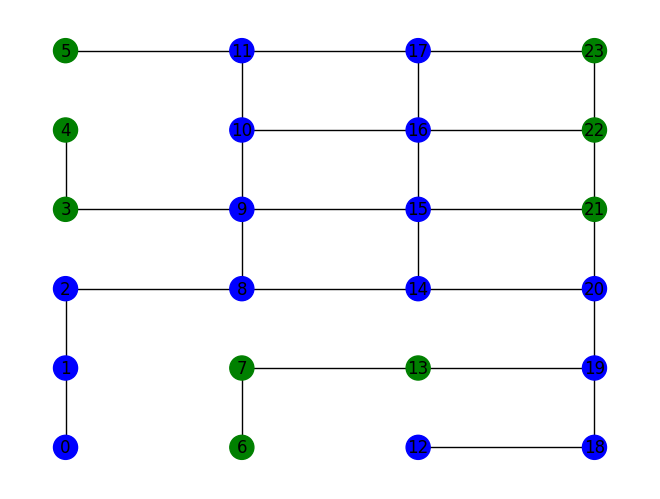

In [112]:
color_map = []
for node in g:
    if node in path:
        color_map.append("blue")
    else:
        color_map.append("green")
nx.draw(g, labels=nx.get_node_attributes(g, "data"), pos=pos, node_color=color_map)

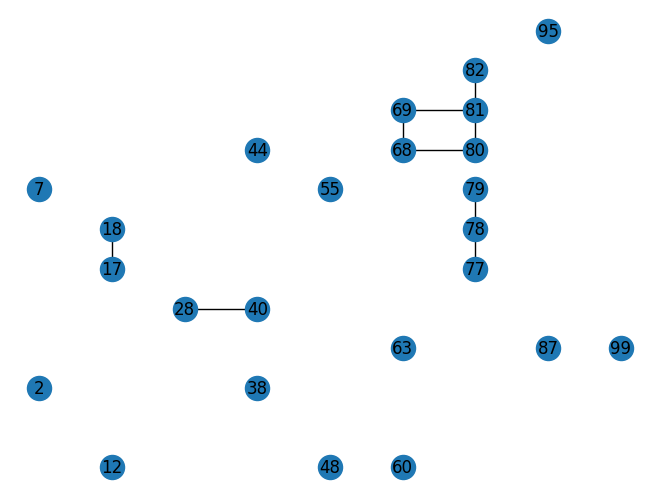

In [32]:
sub_graph = g.subgraph(nodes=[r.pos for r in result])
spos = {node: node for node in sub_graph.nodes()}

nx.draw(sub_graph, labels=nx.get_node_attributes(sub_graph, "data"), pos=pos)